<a href="https://colab.research.google.com/github/Nanji03/SOEN471_A2_Group20_Repo/blob/main/SOEN471_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## All the used dependencies

In [1]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import warnings
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from IPython.display import display
from sklearn.model_selection import train_test_split
import networkx as nx

warnings.filterwarnings("ignore")

## Part 1: Data Preprocessing
Steps:
- Load `ecommerce_user_data.csv` and `product_details.csv`
- Merge data if necessary
- Create user-item matrix
- Fill missing ratings with 0
- Group user behavior by category

In [2]:
#Load datasets
user_data = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

print("User data shape:", user_data.shape)
print("Product data shape:", product_data.shape)
print("\nUser data preview:")
print(user_data.head())
print("\nProduct data preview:")
print(product_data.head())

User data shape: (724, 5)
Product data shape: (100, 3)

User data preview:
  UserID ProductID  Rating   Timestamp  Category
0   U000     P0009       5  2024-09-08     Books
1   U000     P0020       1  2024-09-02      Home
2   U000     P0012       4  2024-10-18     Books
3   U000     P0013       1  2024-09-18  Clothing
4   U000     P0070       4  2024-09-16      Toys

Product data preview:
  ProductID      ProductName     Category
0     P0000      Toys Item 0     Clothing
1     P0001  Clothing Item 1  Electronics
2     P0002     Books Item 2  Electronics
3     P0003  Clothing Item 3  Electronics
4     P0004  Clothing Item 4  Electronics


In [3]:
#Clean datasets

#standardize column names
user_data.columns = user_data.columns.str.strip()
product_data.columns = product_data.columns.str.strip()

#remove duplicates
user_data = user_data.drop_duplicates()
product_data = product_data.drop_duplicates()

#convert timestamp to datetime
user_data["Timestamp"] = pd.to_datetime(user_data["Timestamp"], errors="coerce")

#ensure rating is numeric
user_data["Rating"] = pd.to_numeric(user_data["Rating"], errors="coerce")

#drop rows with critical missing values
user_data = user_data.dropna(subset=["UserID", "ProductID", "Rating", "Category"])
product_data = product_data.dropna(subset=["ProductID", "ProductName", "Category"])

#ratings in valid range
user_data = user_data[(user_data["Rating"] >= 1) & (user_data["Rating"] <= 5)]

print("\nMissing values after cleaning:")
print(user_data.isnull().sum())
print(product_data.isnull().sum())


Missing values after cleaning:
UserID       0
ProductID    0
Rating       0
Timestamp    0
Category     0
dtype: int64
ProductID      0
ProductName    0
Category       0
dtype: int64


In [4]:
## Merge user data with product details

## Drop product category before merging
product_data_clean = product_data.drop(columns=["Category"], errors="ignore").copy()

## Merge user data with cleaned product details
merged_data = pd.merge(
    user_data,
    product_data_clean,
    on="ProductID",
    how="left",
    suffixes=("_user", "_product")
)

## Create category from the first word of Product Name
merged_data["Category"] = (
    merged_data["ProductName"]
    .str.strip()
    .str.split()
    .str[0]
)

print("\nMerged data preview:")
print(merged_data.head())


Merged data preview:
  UserID ProductID  Rating  Timestamp  Category       ProductName
0   U000     P0009       5 2024-09-08  Clothing   Clothing Item 9
1   U000     P0020       1 2024-09-02  Clothing  Clothing Item 20
2   U000     P0012       4 2024-10-18    Beauty    Beauty Item 12
3   U000     P0013       1 2024-09-18  Clothing  Clothing Item 13
4   U000     P0070       4 2024-09-16    Beauty    Beauty Item 70


In [5]:
#Create user-item matrix

user_item_matrix = merged_data.pivot_table(
    index="UserID",
    columns="ProductID",
    values="Rating",
    aggfunc="mean"
)

print("\nUser-item matrix shape:", user_item_matrix.shape)
print(user_item_matrix.head())


User-item matrix shape: (50, 100)
ProductID  P0000  P0001  P0002  P0003  P0004  P0005  P0006  P0007  P0008  \
UserID                                                                     
U000         NaN    NaN    NaN    3.0    NaN    5.0    NaN    3.0    NaN   
U001         NaN    NaN    3.0    NaN    NaN    NaN    NaN    NaN    NaN   
U002         NaN    NaN    NaN    NaN    NaN    5.0    NaN    NaN    NaN   
U003         NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
U004         NaN    3.0    NaN    NaN    NaN    NaN    2.0    NaN    NaN   

ProductID  P0009  ...  P0090  P0091  P0092  P0093  P0094  P0095  P0096  P0097  \
UserID            ...                                                           
U000         5.0  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
U001         NaN  ...    NaN    5.0    NaN    NaN    NaN    3.0    NaN    NaN   
U002         NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
U003         NaN  ...    Na

In [6]:
#Handle missing ratings

#unrated items are filled with 0
user_item_matrix_filled = user_item_matrix.fillna(0)

print("\nUser-item matrix after filling missing values:")
print(user_item_matrix_filled.head())


User-item matrix after filling missing values:
ProductID  P0000  P0001  P0002  P0003  P0004  P0005  P0006  P0007  P0008  \
UserID                                                                     
U000         0.0    0.0    0.0    3.0    0.0    5.0    0.0    3.0    0.0   
U001         0.0    0.0    3.0    0.0    0.0    0.0    0.0    0.0    0.0   
U002         0.0    0.0    0.0    0.0    0.0    5.0    0.0    0.0    0.0   
U003         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U004         0.0    3.0    0.0    0.0    0.0    0.0    2.0    0.0    0.0   

ProductID  P0009  ...  P0090  P0091  P0092  P0093  P0094  P0095  P0096  P0097  \
UserID            ...                                                           
U000         5.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U001         0.0  ...    0.0    5.0    0.0    0.0    0.0    3.0    0.0    0.0   
U002         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U003         0

In [7]:
#Group and aggregate purchase behavior

user_category_agg = (
    merged_data.groupby(["UserID", "Category"])
    .agg(
        TotalInteractions=("ProductID", "count"),
        AverageRating=("Rating", "mean"),
        UniqueProducts=("ProductID", "nunique")
    )
    .reset_index()
)

print("\nUser-category aggregated behavior:")
print(user_category_agg.head())


User-category aggregated behavior:
  UserID     Category  TotalInteractions  AverageRating  UniqueProducts
0   U000       Beauty                  4           3.00               4
1   U000        Books                  1           3.00               1
2   U000     Clothing                  6           2.50               6
3   U000  Electronics                  3           4.00               3
4   U000         Home                  4           2.75               4


## Part 2: User-Based Collaborative Filtering
Steps:
- Use cosine similarity to compare users
- Recommend top-N products based on similar users
- Evaluate with Precision@K and Coverage

In [8]:
## Train / Test Split, cross validation system: leaving one set of data out
def train_test_split_per_user(matrix, test_ratio=0.3, random_state=42):
    rng = np.random.default_rng(random_state)
    train = matrix.copy()
    test = {}
    for uid in matrix.index:
        rated = matrix.loc[uid][matrix.loc[uid] > 0].index.tolist()
        if len(rated) < 2:
            test[uid] = []
            continue
        n_test = max(1, int(len(rated) * test_ratio))
        n_test = min(n_test, len(rated) - 1)
        held = list(rng.choice(rated, size=n_test, replace=False))
        train.loc[uid, held] = 0
        test[uid] = held
    return train, test

## Mean center ratings for calculating adjusted cosine similarity
def mean_center_matrix(matrix):
    temp = matrix.replace(0, np.nan)
    user_means = temp.mean(axis=1)
    centered = temp.sub(user_means, axis=0)
    return centered.fillna(0), user_means

## Significance weighting
def compute_user_similarity_with_significance(train_matrix, min_common=2):
    centered_matrix, _ = mean_center_matrix(train_matrix)
    sim = cosine_similarity(centered_matrix)
    sim_df = pd.DataFrame(
        sim,
        index=train_matrix.index,
        columns=train_matrix.index
    )
    binary_matrix = (train_matrix > 0).astype(int)
    co_rated = binary_matrix.dot(binary_matrix.T)
    significance = np.minimum(co_rated / min_common, 1.0)
    sim_df = sim_df * significance
    return sim_df

## Popularity fallback
def get_popular_items(train_matrix, top_n=10):
    item_popularity = train_matrix.replace(0, np.nan).mean(axis=0)
    return item_popularity.sort_values(ascending=False).index.tolist()[:top_n]

## Recommendation function
def recommend_products(user_id, user_similarity_df, user_item_matrix, top_n=5, n_neighbors= 5, popular_items=None):
    sim_scores = user_similarity_df.loc[user_id].drop(user_id)
    positive_sim = sim_scores[sim_scores > 0]
    if not positive_sim.empty:
        neighbours = positive_sim.nlargest(n_neighbors)
    else:
        neighbours = sim_scores.nlargest(n_neighbors)

    if neighbours.abs().sum() == 0:
        already_rated = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index.tolist()
        fallback = [item for item in (popular_items or []) if item not in already_rated]
        return fallback[:top_n]

    weighted_sum = user_item_matrix.loc[neighbours.index].T.dot(neighbours)
    predicted = weighted_sum / neighbours.abs().sum()
    already_rated = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index
    predicted = predicted.drop(already_rated, errors='ignore')
    if predicted.empty and popular_items is not None:
        fallback = [item for item in popular_items if item not in already_rated]
        return fallback[:top_n]
    recs = predicted.nlargest(top_n).index.tolist()
    if len(recs) < top_n and popular_items is not None:
        extra = [item for item in popular_items if item not in recs and item not in already_rated]
        recs.extend(extra[: top_n - len(recs)])
    return recs[:top_n]


In [9]:
## Evaluation metrics' definitions
## Precison@K
def precision_at_k(recommended, relevant, k):
    return len(set(recommended[:k]) & set(relevant)) / k

## Recall@K
def recall_at_k(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    return len(set(recommended[:k]) & set(relevant)) / len(relevant)

## Mean Average Precision
def average_precision(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    hits = 0
    sum_prec = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            sum_prec += hits / (i + 1)
    return sum_prec / min(len(relevant), k)

## Catalog coverage
def catalog_coverage(recommendations, n_products):
    unique_items = {item for recs in recommendations.values() for item in recs}
    return len(unique_items) / n_products if n_products > 0 else 0.0

## Intra-list Diversity
def intra_list_diversity(recommendations, item_matrix):
    item_vectors = item_matrix.T
    diversities = []
    for uid, recs in recommendations.items():
        valid = [item for item in recs if item in item_vectors.index]
        if len(valid) < 2:
            diversities.append(0.0)
            continue
        vecs = item_vectors.loc[valid].values
        sim = cosine_similarity(vecs)
        n = len(valid)
        pairwise_distances = [
            1 - sim[i][j]
            for i in range(n)
            for j in range(i + 1, n)
        ]
        diversities.append(np.mean(pairwise_distances))
    return float(np.mean(diversities)) if diversities else 0.0

In [10]:
## Evaluation setup
def evaluate_model(train_matrix, test_dict, n_neighbors, k):
    sim_df = compute_user_similarity_with_significance(train_matrix)
    popular_items = get_popular_items(train_matrix, top_n=50)
    recommendations = {uid: recommend_products(uid, sim_df, train_matrix, top_n=k, n_neighbors=n_neighbors, popular_items=popular_items) for uid in train_matrix.index}

    precisions = [precision_at_k(recommendations[uid], test_dict[uid], k) for uid in train_matrix.index]
    recalls = [recall_at_k(recommendations[uid], test_dict[uid], k) for uid in train_matrix.index]
    avg_precs = [average_precision(recommendations[uid], test_dict[uid], k) for uid in train_matrix.index]
    coverage = catalog_coverage(recommendations, len(train_matrix.columns))
    diversity = intra_list_diversity(recommendations,train_matrix)

    return {'N_NEIGHBORS': n_neighbors, 'K': k, 'Precision@K': np.mean(precisions), 'Recall@K': np.mean(recalls), 'MAP': np.mean(avg_precs),'Catalog Coverage': coverage, 'Intra-List Diversity': diversity}


In [11]:
## Grid search
train_matrix, test_dict = train_test_split_per_user(user_item_matrix_filled)
neighbor_grid = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
k_grid = [3, 5, 6, 7, 8, 9, 10]

results = []
for n_neighbors in neighbor_grid:
    for k in k_grid:
        result = evaluate_model(train_matrix, test_dict, n_neighbors, k)
        results.append(result)
print(f"Done Iterating")

results_df = pd.DataFrame(results).sort_values(by=['MAP', 'Precision@K'], ascending=False)
print("Grid Search Results:")
results_df


Done Iterating
Grid Search Results:


,N_NEIGHBORS,K,Precision@K,Recall@K,MAP,Catalog Coverage,Intra-List Diversity
12,6,9,0.053333,0.117333,0.045958,0.91,0.816758
13,6,10,0.048000,0.117333,0.045958,0.93,0.822256
62,13,10,0.052000,0.129000,0.045607,0.93,0.822748
27,8,10,0.054000,0.130333,0.045587,0.94,0.824526
69,14,10,0.052000,0.129000,0.045512,0.93,0.822858
...,...,...,...,...,...,...,...
44,11,6,0.056667,0.083333,0.035467,0.79,0.798141
71,15,5,0.052000,0.064667,0.035306,0.72,0.793112
50,12,5,0.052000,0.064667,0.034222,0.72,0.795313
36,10,5,0.056000,0.068667,0.034189,0.75,0.793498


In [12]:
## Optimum Hyperparameters
best_row = results_df.iloc[0]
print("Best Configuration:")
print(best_row)

Best Configuration:
N_NEIGHBORS             6.000000
K                       9.000000
Precision@K             0.053333
Recall@K                0.117333
MAP                     0.045958
Catalog Coverage        0.910000
Intra-List Diversity    0.816758
Name: 12, dtype: float64


In [13]:
## Final recommended products with optimal hyperparameters found
best_n_neighbors = 9
best_k = 6

best_sim_df = compute_user_similarity_with_significance(train_matrix)
popular_items = get_popular_items(train_matrix, top_n=50)

best_recommendations = {uid: recommend_products(uid, best_sim_df, train_matrix, top_n=best_k, n_neighbors=best_n_neighbors,popular_items=popular_items)for uid in train_matrix.index}

print("Top-6 Product Recommendations for All Users")
print("=" * 70)

for uid in train_matrix.index:
    recs = best_recommendations[uid]
    names = product_data[product_data['ProductID'].isin(recs)]['ProductName'].tolist() if 'product_data' in globals() else []
    print(f"User {uid}:")
    print(f"Recommended Product IDs   : {recs}")
    if names:
        print(f"Recommended Product Names : {names}")


Top-6 Product Recommendations for All Users
User U000:
Recommended Product IDs   : ['P0051', 'P0063', 'P0070', 'P0040', 'P0010', 'P0032']
Recommended Product Names : ['Toys Item 10', 'Toys Item 32', 'Electronics Item 40', 'Home Item 51', 'Beauty Item 63', 'Beauty Item 70']
User U001:
Recommended Product IDs   : ['P0070', 'P0071', 'P0062', 'P0064', 'P0000', 'P0087']
Recommended Product Names : ['Toys Item 0', 'Books Item 62', 'Electronics Item 64', 'Beauty Item 70', 'Beauty Item 71', 'Beauty Item 87']
User U002:
Recommended Product IDs   : ['P0041', 'P0079', 'P0025', 'P0004', 'P0034', 'P0003']
Recommended Product Names : ['Clothing Item 3', 'Clothing Item 4', 'Clothing Item 25', 'Beauty Item 34', 'Books Item 41', 'Home Item 79']
User U003:
Recommended Product IDs   : ['P0079', 'P0041', 'P0070', 'P0012', 'P0048', 'P0009']
Recommended Product Names : ['Clothing Item 9', 'Beauty Item 12', 'Books Item 41', 'Electronics Item 48', 'Beauty Item 70', 'Home Item 79']
User U004:
Recommended Produ

## Part 3: Association Rule Mining (Apriori)
Steps:
- Convert user-product interactions to transaction format
- Apply Apriori algorithm to find frequent itemsets
- Generate association rules (support, confidence, lift)

In [14]:
## Suppress deprecation warnings for clean output
warnings.filterwarnings('ignore')

## Convert user-product interactions to transaction format using Product Names
transactions = merged_data.groupby('UserID')['ProductName'].apply(list).tolist()

## Initialize and apply the TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

## Split the transactions dataset into train and test sets
train_df, test_df = train_test_split(df_trans, test_size=0.2, random_state=42)

## Define hyperparamter grid for grid search
param_grid = {
    'min_support': [ 0.05, 0.1],
    'metric': ['confidence', 'lift'],
    'min_threshold': [0.5, 1.0]
}

## Define evaluation metrics on test set
def evaluate_rules_on_test(rules, test_df):
    if rules.empty:
        return 0

    supports = []

    for _, rule in rules.iterrows():
        antecedent = list(rule['antecedents'])
        consequent = list(rule['consequents'])
        items = antecedent + consequent

        valid_items = [col for col in items if col in test_df.columns]

        if len(valid_items) == 0:
            continue

        mask = test_df[valid_items].all(axis=1)
        support = mask.mean()
        supports.append(support)

    return sum(supports) / len(supports) if supports else 0

Top 10 Association Rules Discovered:


,antecedents,consequents,support,confidence,lift
416,"(Home Item 52, Beauty Item 50)","(Books Item 6, Books Item 11)",0.06,1.0,16.666667
417,"(Home Item 52, Books Item 6)","(Beauty Item 50, Books Item 11)",0.06,1.0,16.666667
420,"(Beauty Item 50, Books Item 11)","(Home Item 52, Books Item 6)",0.06,1.0,16.666667
421,"(Books Item 6, Books Item 11)","(Home Item 52, Beauty Item 50)",0.06,1.0,16.666667
456,"(Clothing Item 88, Clothing Item 13)","(Clothing Item 44, Electronics Item 64)",0.06,1.0,16.666667
461,"(Clothing Item 44, Electronics Item 64)","(Clothing Item 88, Clothing Item 13)",0.06,1.0,16.666667
488,"(Electronics Item 64, Clothing Item 13)","(Clothing Item 88, Home Item 79)",0.06,1.0,16.666667
489,"(Clothing Item 88, Home Item 79)","(Electronics Item 64, Clothing Item 13)",0.06,1.0,16.666667
496,"(Clothing Item 88, Home Item 79)","(Clothing Item 44, Electronics Item 64)",0.06,1.0,16.666667
501,"(Clothing Item 44, Electronics Item 64)","(Clothing Item 88, Home Item 79)",0.06,1.0,16.666667


In [ ]:
## Result of grid search
results = []

for min_support, metric, min_threshold in itertools.product(
    param_grid['min_support'],
    param_grid['metric'],
    param_grid['min_threshold']):

    frequent_itemsets = apriori(
    train_df,
    min_support=min_support,
    use_colnames=True
    )

    if frequent_itemsets.empty:
        continue

    rules = association_rules(
        frequent_itemsets,
        metric=metric,
        min_threshold=min_threshold
    )

    if rules.empty:
        continue

    test_score = evaluate_rules_on_test(rules, test_df)
    results.append({
        'min_support': min_support,
        'metric': metric,
        'min_threshold': min_threshold,
        'num_rules': len(rules),
        'avg_lift': rules['lift'].mean(),
        'test_score': test_score
    })

results_df = pd.DataFrame(results)

print("Grid Search Results:")
display(results_df.sort_values(by='test_score', ascending=False))

In [ ]:
## Optimal hyperparameters
best_result = results_df.sort_values(by='test_score', ascending=False).iloc[0]

print("Best Parameters:")
print(best_result)

In [ ]:
## Apply Apriori to find the frequent itemsets using the optimal hyperparameter
best_frequent_itemsets = apriori(df_trans, min_support=best_result['min_support'], use_colnames=True)

best_rules = association_rules(best_frequent_itemsets, metric=best_result['metric'], min_threshold=best_result['min_threshold'])

best_rules = best_rules.sort_values(by='lift', ascending=False)

print("Top Association Rules:")
display(best_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))

## Part 4: Visualization
Steps:
- Plot user similarity heatmap
- Visualize top recommendations
- Plot top frequent itemsets

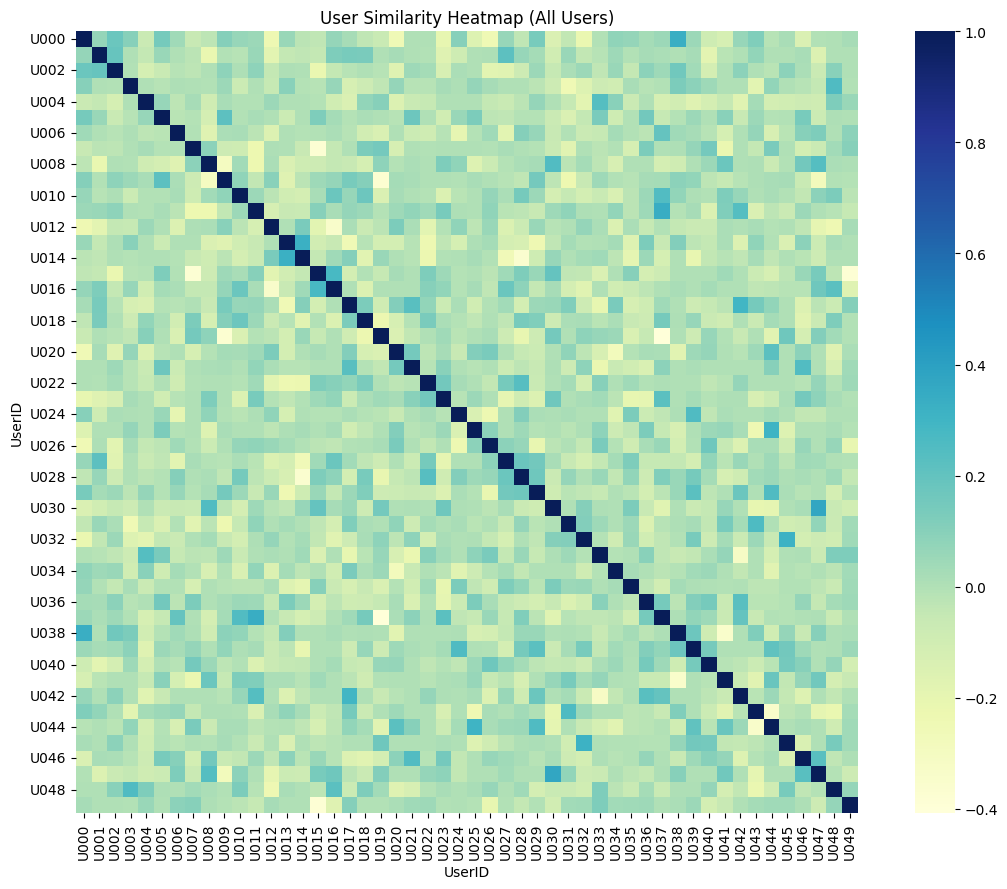

In [37]:
#User similarity heatmaps
user_similarity_df = compute_user_similarity_with_significance(user_item_matrix_filled)
plt.figure(figsize=(12, 9))
sns.heatmap(user_similarity_df, cmap="YlGnBu", square=True)
plt.title("User Similarity Heatmap (All Users)")
plt.xlabel("UserID")
plt.ylabel("UserID")
plt.tight_layout()
plt.show()

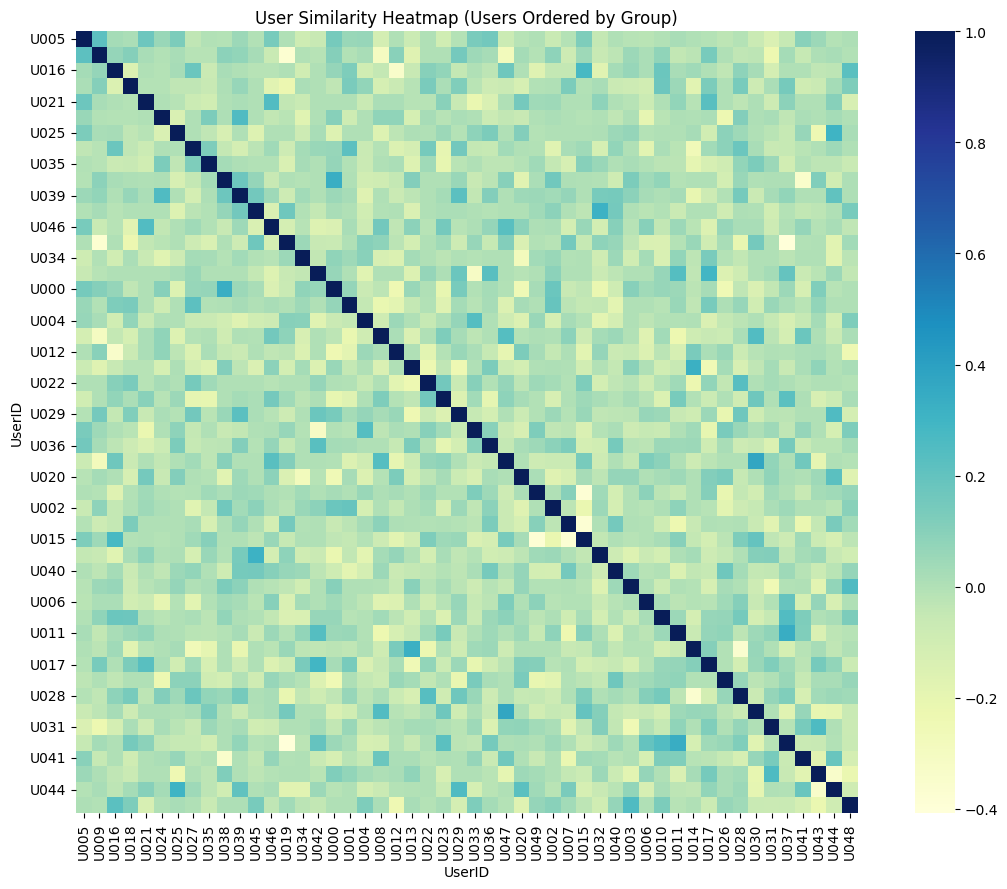

In [18]:
user_groups = (
    merged_data.groupby(["UserID", "Category"])
        .size()
        .reset_index(name="Count")
        .sort_values(["UserID", "Count"], ascending=[True, False])
        .drop_duplicates("UserID")
        .rename(columns={"Category": "UserGroup"})
)

ordered_users = user_groups.sort_values(["UserGroup", "UserID"])["UserID"].tolist()
similarity_by_group = user_similarity_df.loc[ordered_users, ordered_users]

plt.figure(figsize=(12, 9))
sns.heatmap(similarity_by_group, cmap="YlGnBu", square=True)
plt.title("User Similarity Heatmap (Users Ordered by Group)")
plt.xlabel("UserID")
plt.ylabel("UserID")
plt.tight_layout()
plt.show()

In [19]:
#Top-5 product recommendations for each user group

#convert the dictionary of recommendations into DataFrame
all_recs_list = []
for user_id, product_ids in best_recommendations.items():
    for product_id in product_ids:
        all_recs_list.append({'UserID': user_id, 'ProductID': product_id, 'Score': 1.0})

all_user_recommendations = pd.DataFrame(all_recs_list)

#Merge with product_data to get ProductName and Category details
all_user_recommendations = pd.merge(
    all_user_recommendations,
    merged_data[['ProductID', 'ProductName', 'Category']],
    on='ProductID',
    how='left'
)

group_recommendations = (
    all_user_recommendations
    .merge(user_groups, on="UserID", how="left")
    .groupby(["UserGroup", "ProductID", "ProductName", "Category"], dropna=False)
    .agg(
        MeanRecommendationScore=("Score", "mean"),
        RecommendedToUsers=("UserID", "nunique")
    )
    .reset_index()
)

group_recommendations["GroupRankScore"] = (
    0.7 * group_recommendations["MeanRecommendationScore"] +
    0.3 * group_recommendations["RecommendedToUsers"]
)

top5_group_recommendations = (
    group_recommendations
    .sort_values(["UserGroup", "GroupRankScore", "MeanRecommendationScore"], ascending=[True, False, False])
    .groupby("UserGroup")
    .head(5)
    .reset_index(drop=True)
)

display(top5_group_recommendations)

,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers,GroupRankScore
0,Beauty,P0070,Beauty Item 70,Beauty,1.0,5,2.2
1,Beauty,P0005,Home Item 5,Home,1.0,4,1.9
2,Beauty,P0064,Electronics Item 64,Electronics,1.0,4,1.9
3,Beauty,P0089,Clothing Item 89,Clothing,1.0,4,1.9
4,Beauty,P0033,Toys Item 33,Toys,1.0,3,1.6
5,Books,P0001,Clothing Item 1,Clothing,1.0,2,1.3
6,Books,P0065,Toys Item 65,Toys,1.0,2,1.3
7,Books,P0070,Beauty Item 70,Beauty,1.0,2,1.3
8,Books,P0006,Books Item 6,Books,1.0,1,1.0
9,Books,P0018,Home Item 18,Home,1.0,1,1.0


In [20]:
#Tabular summary for report
group_summary = user_groups.groupby("UserGroup").agg(
    UsersInGroup=("UserID", "nunique")
).reset_index()

display(group_summary)

for group_id in sorted(top5_group_recommendations["UserGroup"].dropna().unique()):
    print(f"\nTop-5 recommendations for User Group {group_id}")
    display(
        top5_group_recommendations.loc[top5_group_recommendations["UserGroup"] == group_id, [
            "UserGroup", "ProductID", "ProductName", "Category",
            "MeanRecommendationScore", "RecommendedToUsers"
        ]].reset_index(drop=True)
    )

,UserGroup,UsersInGroup
0,Beauty,13
1,Books,3
2,Clothing,12
3,Electronics,2
4,Home,5
5,Toys,15



Top-5 recommendations for User Group Beauty


,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers
0,Beauty,P0070,Beauty Item 70,Beauty,1.0,5
1,Beauty,P0005,Home Item 5,Home,1.0,4
2,Beauty,P0064,Electronics Item 64,Electronics,1.0,4
3,Beauty,P0089,Clothing Item 89,Clothing,1.0,4
4,Beauty,P0033,Toys Item 33,Toys,1.0,3



Top-5 recommendations for User Group Books


,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers
0,Books,P0001,Clothing Item 1,Clothing,1.0,2
1,Books,P0065,Toys Item 65,Toys,1.0,2
2,Books,P0070,Beauty Item 70,Beauty,1.0,2
3,Books,P0006,Books Item 6,Books,1.0,1
4,Books,P0018,Home Item 18,Home,1.0,1


...

,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers
0,Electronics,P0015,Toys Item 15,Toys,1.0,2
1,Electronics,P0008,Books Item 8,Books,1.0,1
2,Electronics,P0010,Toys Item 10,Toys,1.0,1
3,Electronics,P0016,Beauty Item 16,Beauty,1.0,1
4,Electronics,P0020,Clothing Item 20,Clothing,1.0,1



Top-5 recommendations for User Group Home


,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers
0,Home,P0070,Beauty Item 70,Beauty,1.0,3
1,Home,P0041,Books Item 41,Books,1.0,2
2,Home,P0003,Clothing Item 3,Clothing,1.0,1
3,Home,P0004,Clothing Item 4,Clothing,1.0,1
4,Home,P0010,Toys Item 10,Toys,1.0,1



Top-5 recommendations for User Group Toys


,UserGroup,ProductID,ProductName,Category,MeanRecommendationScore,RecommendedToUsers
0,Toys,P0070,Beauty Item 70,Beauty,1.0,5
1,Toys,P0088,Clothing Item 88,Clothing,1.0,5
2,Toys,P0030,Books Item 30,Books,1.0,4
3,Toys,P0005,Home Item 5,Home,1.0,3
4,Toys,P0041,Books Item 41,Books,1.0,3


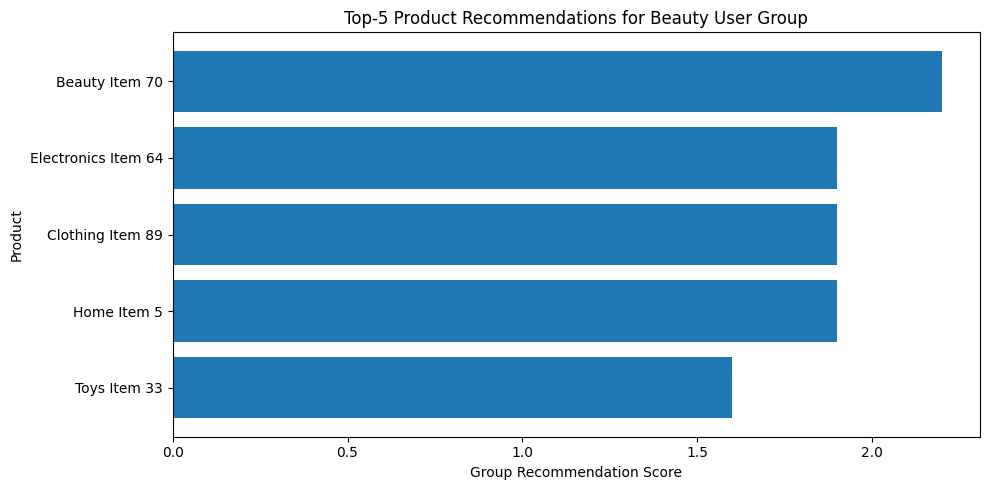

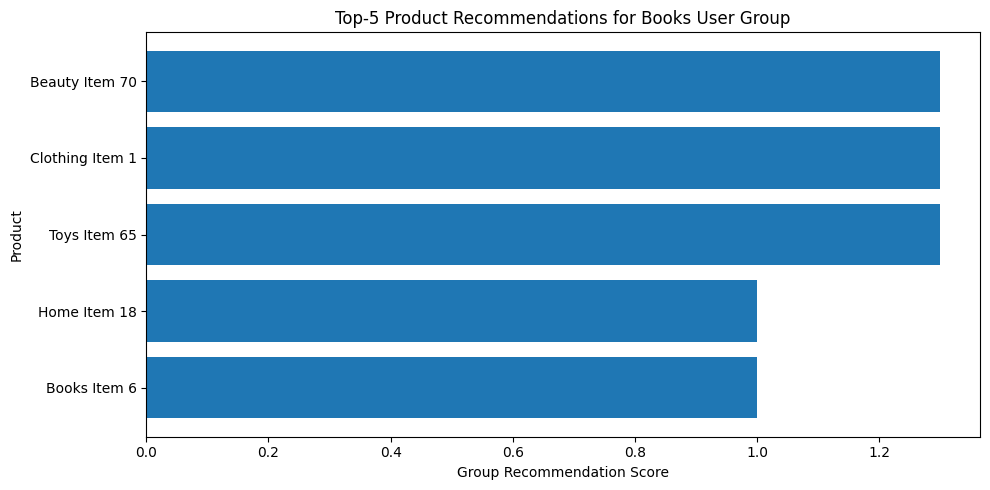

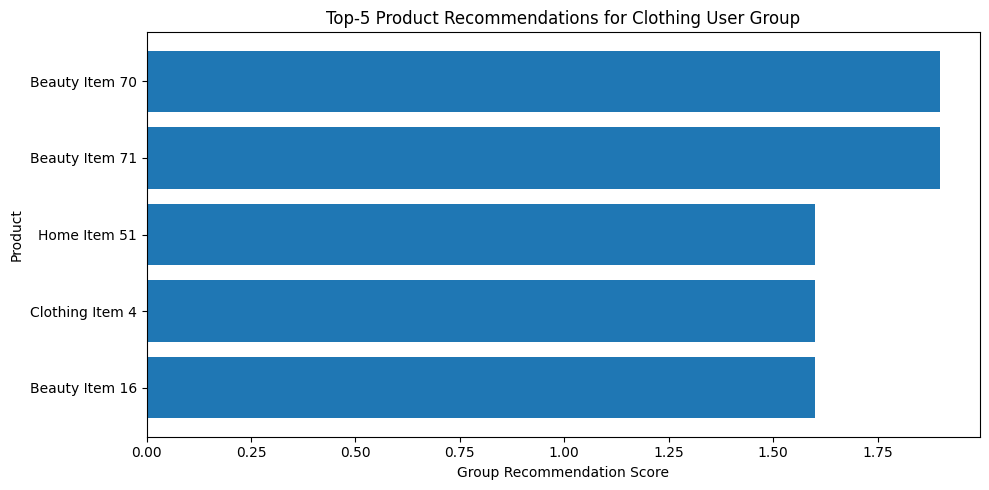

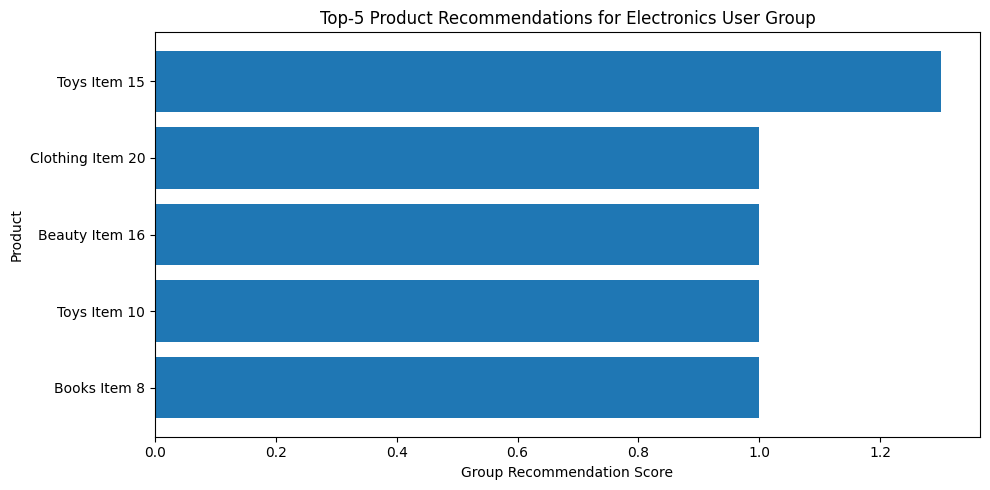

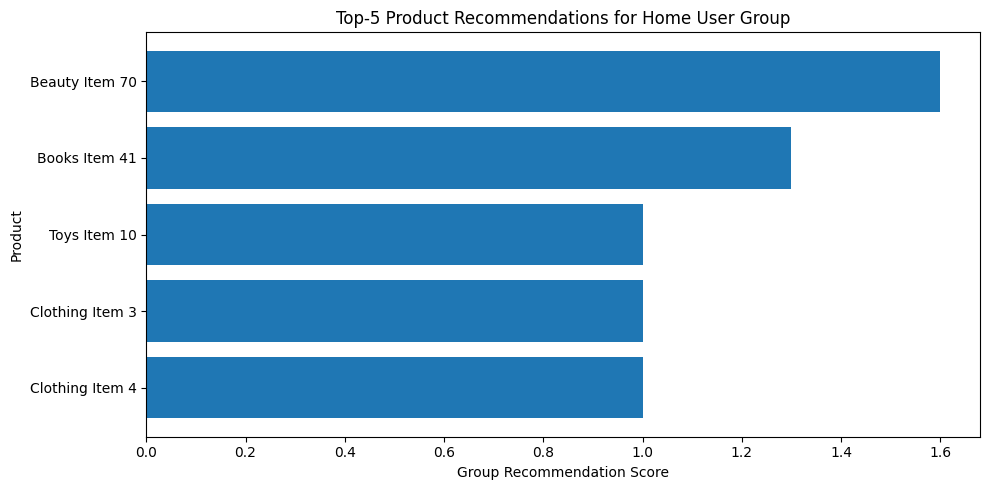

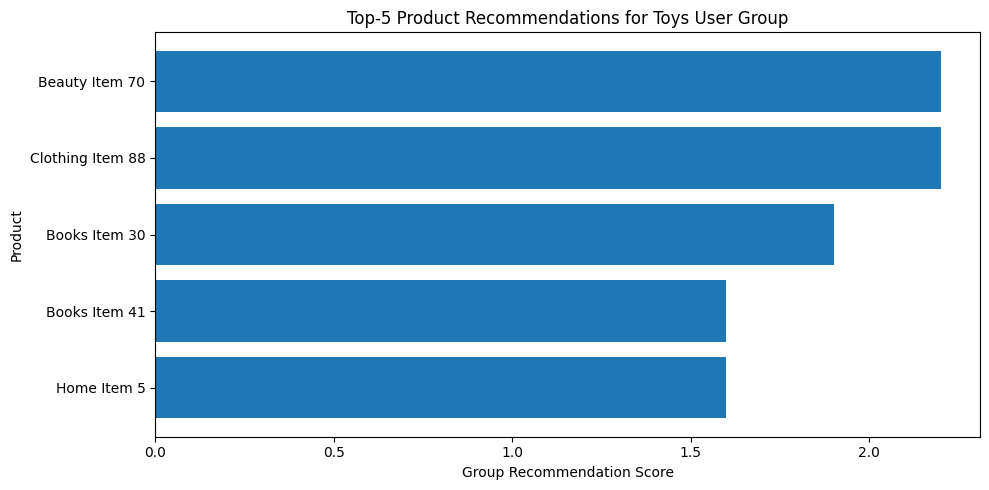

In [21]:
#Visualization 3: bar chart for each user group's top-5 recommendations
for group_id in sorted(top5_group_recommendations["UserGroup"].dropna().unique()):
    plot_df = (
        top5_group_recommendations[top5_group_recommendations["UserGroup"] == group_id]
        .sort_values("GroupRankScore", ascending=True)
    )

    plt.figure(figsize=(10, 5))
    plt.barh(plot_df["ProductName"].fillna(plot_df["ProductID"]), plot_df["GroupRankScore"])
    plt.title(f"Top-5 Product Recommendations for {group_id} User Group")
    plt.xlabel("Group Recommendation Score")
    plt.ylabel("Product")
    plt.tight_layout()
    plt.show()

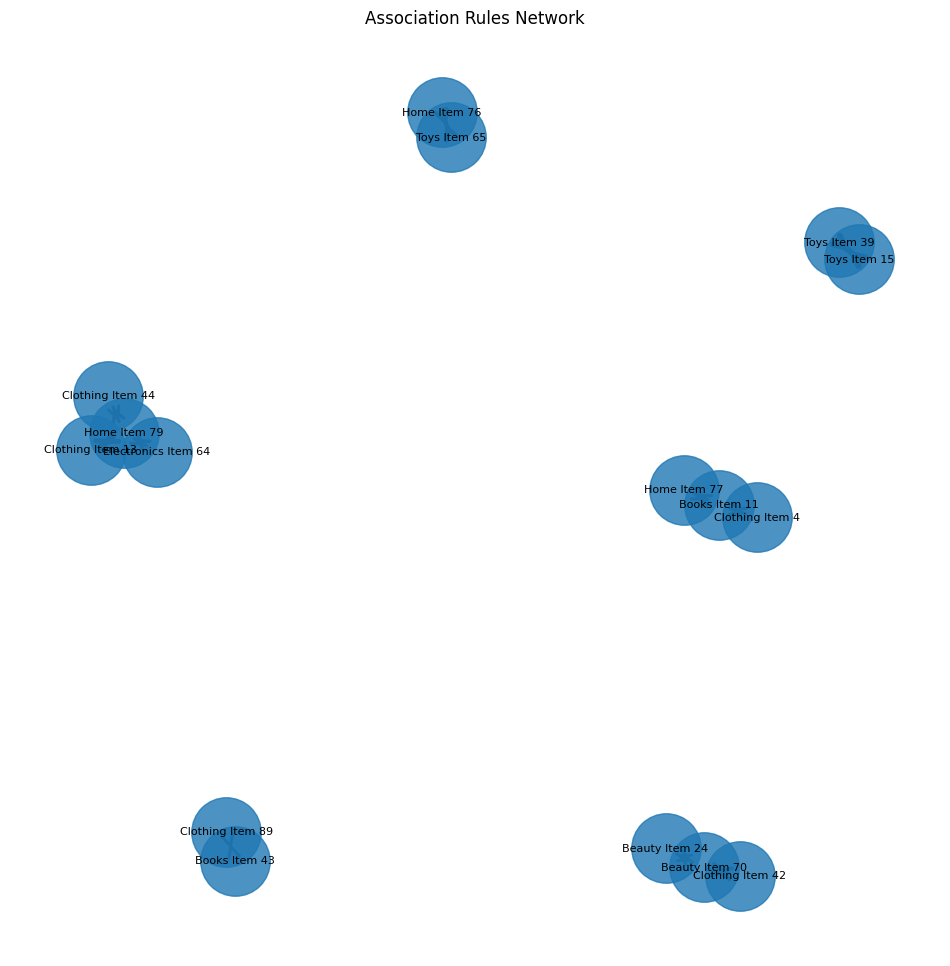

In [ ]:
## Visualize the itemsets and the associations using a network
plot_rules = best_rules.head(20)

G = nx.DiGraph()

for _, row in plot_rules.iterrows():
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))

    G.add_edge(antecedents, consequents, weight=row['lift'])

plt.figure(figsize=(10, 10))

pos = nx.spring_layout(G, seed=42)

edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

nx.draw_networkx_nodes(G, pos, node_size=2500, alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, width=weights)

plt.title('Association Rules Network')
plt.axis('off')
plt.show()